In [1]:
import sys
import os
import pytest

import jax
import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
import equinox as eqx

import amigo as amg
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller

from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

plt.style.use(['science',  'bright', 'no-latex'])
new_rcParams = {
    'image.cmap': 'inferno',
    'font.family': 'serif',
    'image.origin': 'lower',
    'figure.dpi': 300,
    'font.size': 8,
    'xtick.direction': 'out',
    'ytick.direction': 'out'
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps['inferno']
viridis = mpl.colormaps['viridis']
seismic = mpl.colormaps['seismic']
coolwarm = mpl.colormaps['coolwarm']

inferno.set_bad('k', 0.5)
viridis.set_bad('k', 0.5)
seismic.set_bad('k', 0.5)
coolwarm.set_bad('k', 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf
from frito import TransformedResolvedDiscoModel as TRDM,AutoencoderBasis, TransformedResolvedOIFit as TROIF, PointResolvedOIFit as PROIF, PointResolvedDiscoModel as PRDM

/Users/jonahgoldfine/Documents/Important Documents/packages/frito/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
master_key              = jr.key(0)
main_data_path          = '_data'
autoencoder_data_path   = os.path.join(main_data_path, 'autoencoder')
main_trained_model_path = os.path.join(autoencoder_data_path, 'trained_models')
main_svd_path           = os.path.join(autoencoder_data_path, 'svd')
training_data_path      = os.path.join(autoencoder_data_path, 'training_data')
emnist_path             = os.path.join(training_data_path, 'emnist.npz')
mnist_path              = os.path.join(training_data_path, 'mnist.npz')
ppd_51_path             = os.path.join(training_data_path, 'fake_intensity_PPDs_51x51.npz')

main_out_path           = '_output'
main_model_struct_path  = 'src/frito/autoencoder/model_structures'

ppd_51x51_data          = np.load(ppd_51_path)
test_51x51_data         = ppd_51x51_data['x_test']

disco_HD135344B_path = os.path.join(main_data_path, 'jwst', 'HD135344B', 'disco', 'cal_vis_HD135344B.npy')

In [3]:
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

In [4]:
disco_HD135344B['F480M'].keys()

dict_keys(['u', 'v', 'vis_mat', 'phi_mat', 'K_vis_mat', 'K_phi_mat', 'parang', 'wavel', 'O_vis', 'O_phi', 'O_vis_cov', 'O_phi_cov', 'O_vis_mat', 'O_phi_mat', 'O_vis_eigv', 'O_phi_eigv', 'disco_vis_mat', 'disco_phi_mat', 'K_vis', 'K_vis_cov', 'K_phi', 'K_phi_cov', 'vis', 'vis_cov', 'phi', 'phi_cov'])

In [5]:
model_key, master_key   = jr.split(master_key, 2)
model_type              = 'PPD'
i                           = 16
model_names             = [
                            "0_0", "0_2", "1_0", "1_2", 
                            "2_0", "2_1", "2_2", "3_0", 
                            "3_1", "3_2", "4_0", "4_1", 
                            "4_2", "7_0", "7_1", "7_2", 
                            "7_4", "7_5", "8_0", "8_2", 
                            "8_3", "8_4", "8_5", "8_6"
                            ]
model_name              = model_names[i]
model_struct_path       = os.path.join(main_model_struct_path, f'model_{model_name}.py')
trained_model_path      = os.path.join(main_trained_model_path, model_type, f'{model_name}_best.eqx')
autoencoder_classes     = lcf(model_struct_path)
autoencoder             = autoencoder_classes['autoencoder'](key=model_key)
base_autoencoder        = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f'Model Struct: {model_struct_path}')
print(f'Trained Model Path: {trained_model_path}')
print(f'Autoencoder Classes: {autoencoder_classes}')

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


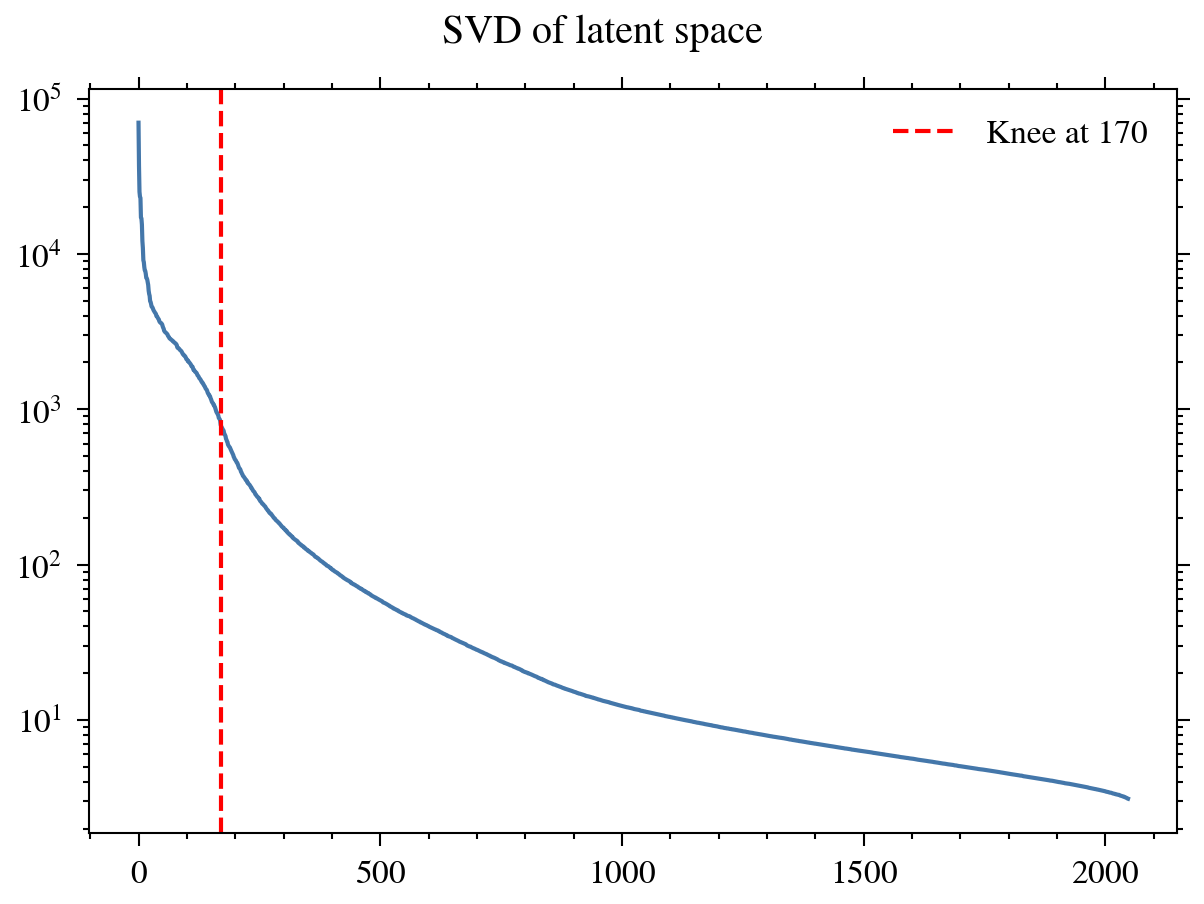

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [6]:
svd_path    = os.path.join(main_svd_path, f'{model_type}_model_{model_name}_svd.npz')
svd         = np.load(svd_path)

k1          = KneeLocator(np.arange(len(svd['s'])), svd['s'], curve='convex', direction='decreasing', online=True)

fig, ax     = plt.subplots(figsize=(4,3), layout='constrained')
fig.suptitle('SVD of latent space')
ax.plot(svd['s'], marker=',')
ax.axvline(k1.knee, color='r', linestyle='--', label=f'Knee at {k1.knee}')
ax.legend()
ax.set_yscale('log')
plt.show()

print(f'SVD Path: {svd_path}')
print(f'Knee at {k1.knee}')

In [15]:
tmp_keys                    = jr.split(master_key, 3)
suture_keys                = tmp_keys[:2]
master_key                  = tmp_keys[2]

new_encode_in               = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out              = int(k1.knee)
new_encode_latent_weights   = base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
new_encode_latent_biases    = base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
new_encode_linear           = eqx.nn.Linear(in_features=new_encode_in,
                                           out_features=new_encode_out, key=suture_keys[0])
trained_new_encode_linear   = eqx.tree_at(lambda l: l.weight, new_encode_linear,
                                         new_encode_latent_weights)
trained_new_encode_linear   = eqx.tree_at(lambda l: l.bias, trained_new_encode_linear,
                                         new_encode_latent_biases)
sutured_ae_struct           = eqx.tree_at(lambda m: m.modules[0].layers[-1],
                                         base_autoencoder, trained_new_encode_linear)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / knee)

embed_layer   = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd['mean'], svd['s'], svd['v'])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers, sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer]
)

def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / knee)) @ v[:knee, :knee] + m[:knee]

unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd['mean'], svd['s'], svd['v'])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers, sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers
)

new_decode_out              = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in               = int(k1.knee)
new_decode_latent_weights   = sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
new_decode_latent_biases    = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear           = eqx.nn.Linear(in_features=new_decode_in,
                                             out_features=new_decode_out, key=suture_keys[1])
trained_new_decode_linear   = eqx.tree_at(lambda l: l.weight, new_decode_linear,
                                           new_decode_latent_weights)
trained_new_decode_linear   = eqx.tree_at(lambda l: l.bias, trained_new_decode_linear,
                                           new_decode_latent_biases)
sutured_ae_struct           = eqx.tree_at(lambda m: m.modules[1].layers[2],
                                           sutured_ae_struct, trained_new_decode_linear)

sutured_model_path          = os.path.join(main_trained_model_path, model_type, f'{model_name}_Rbest.eqx')
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f'Suture Model Path: {sutured_model_path}')

def sum2unity(X):
    return X / np.sum(X, axis=(1, 2), keepdims=True)

sum2unity_layer     = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae     = eqx.tree_at(
        lambda m: m.modules[1].layers,
        sutured_ae,
        sutured_ae.modules[1].layers + [sum2unity_layer]
)

encoder, decoder    = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


Text(0.5, 1.0, 'Initial Distribution | Sum: 1.000000238418579')

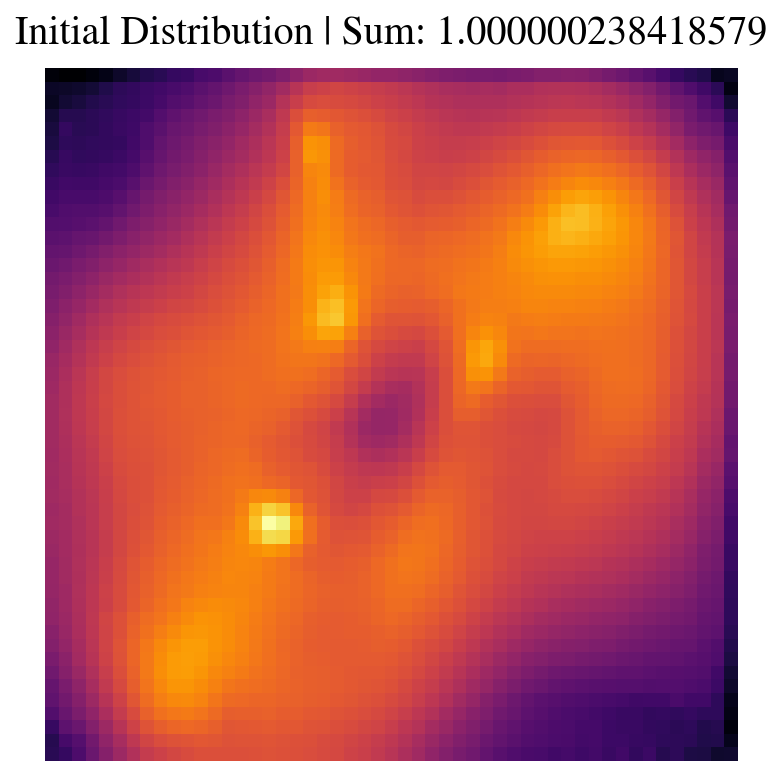

In [16]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)[0]
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f'Initial Distribution | Sum: {np.sum(init_dist)}')

In [17]:
optics_diameter = 6.603464
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)
basis = AutoencoderBasis(norm_sutured_ae)
ois = [PROIF(oi_data, key, filter=key,) for key, oi_data in disco_HD135344B.items()]

In [18]:
model = PRDM(
    ois = ois,
    distribution = init_dist,
    basis = basis,
    contrast = 0.045,
    uv_npixels = 2 * otf_coords.shape[-1],
    uv_pscale = 0.5 * np.diff(otf_coords[0,0]).mean(),
    oversample = 2.0
    
)

PointResolvedOIFit(
  u=f32[1300],
  v=f32[1300],
  wavel=f32[],
  parang=f32[],
  vis=f32[349],
  d_vis=f32[349],
  phi=f32[349],
  d_phi=f32[349],
  vis_mat=f32[349,1300],
  phi_mat=f32[349,1300],
  key='F380M',
  filter='F380M'
)
PointResolvedOIFit(
  u=f32[1300],
  v=f32[1300],
  wavel=f32[],
  parang=f32[],
  vis=f32[349],
  d_vis=f32[349],
  phi=f32[349],
  d_phi=f32[349],
  vis_mat=f32[349,1300],
  phi_mat=f32[349,1300],
  key='F430M',
  filter='F430M'
)
PointResolvedOIFit(
  u=f32[1300],
  v=f32[1300],
  wavel=f32[],
  parang=f32[],
  vis=f32[349],
  d_vis=f32[349],
  phi=f32[349],
  d_phi=f32[349],
  vis_mat=f32[349,1300],
  phi_mat=f32[349,1300],
  key='F480M',
  filter='F480M'
)


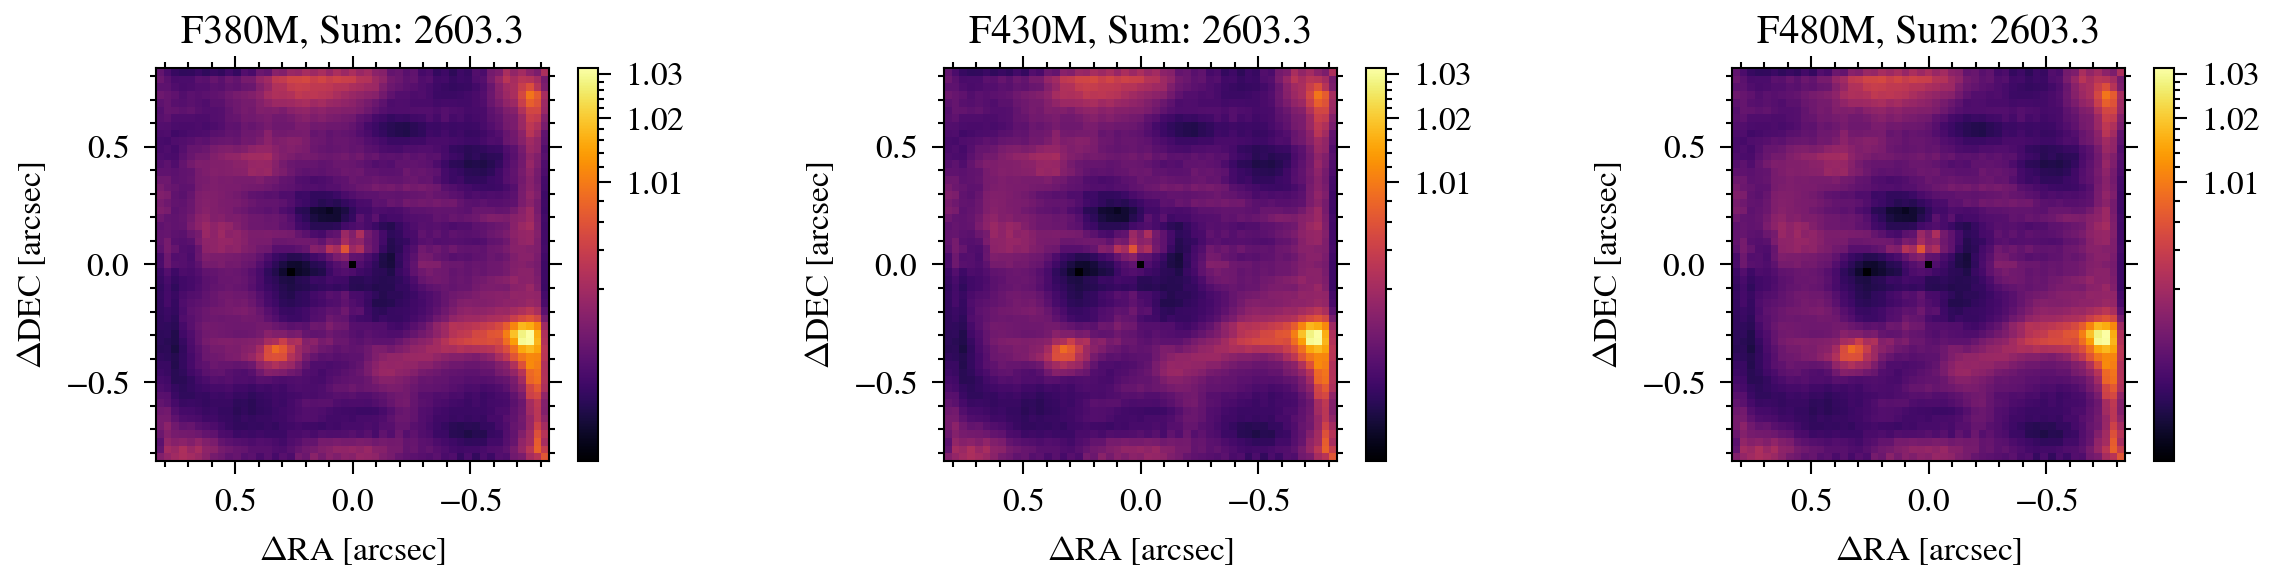

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(8, 2))

for idx, oi in enumerate(ois):
    print(oi)
    init_dist = model.get_distribution(oi)

    c0 = drt.plotting.plot_result(
        ax[idx],
        init_dist.at[init_dist.shape[0] // 2, init_dist.shape[1] // 2].set(np.nan),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap=inferno,
        norm=mpl.colors.PowerNorm(0.3),
    )
    fig.colorbar(c0, ax=ax[idx])
    ax[idx].set(title=f"{oi.filter}, Sum: {init_dist.sum():.1f}")

plt.tight_layout()
plt.show()